In [8]:
import numpy as np
import pandas as pd

data_dir = "../../python_code/experiment_3/runB_02"

# 角度组（来自 runB_02 的文件名）
angle_groups = [80, 85, 87.5, 88.75, 90]

# 用字典存储所有 DataFrame
dfs = {}

for angle in angle_groups:
    base_num = angle_groups.index(angle) * 2 + 1
    micro_num = base_num + 1
    
    # 文件名中的角度格式：整数带 p00，小数带 p50/p75
    angle_str = f"{angle:.2f}".replace(".", "p")
    
    base_file = f"{data_dir}/run_B_02_angle_{angle_str}deg_{base_num:03d}_baseline_RK4_0.0100_300s.parquet"
    micro_file = f"{data_dir}/run_B_02_angle_{angle_str}deg_{micro_num:03d}_micro_RK4_0.0100_300s.parquet"
    
    dfs[(angle, "baseline")] = pd.read_parquet(base_file)
    dfs[(angle, "micro")] = pd.read_parquet(micro_file)

In [9]:
# ========== 1. 每组每条线的两个角度存为 list ==========
angle_lists = {}

for angle in angle_groups:
    for typ in ["baseline", "micro"]:
        df = dfs[(angle, typ)]
        angle_lists[(angle, typ)] = df[["theta_1", "theta_2"]].values.tolist()

In [10]:
# ========== 2. 组内求欧几里得距离 ==========
distance_tables = {}

for angle in angle_groups:
    baseline_arr = np.array(angle_lists[(angle, "baseline")])
    micro_arr   = np.array(angle_lists[(angle, "micro")])
    
    diffs = baseline_arr - micro_arr
    distances = np.sqrt(np.sum(diffs**2, axis=1))
    
    distance_tables[angle] = distances.tolist()

print("✅ angle_lists 和 distance_tables 已生成")
print(f"   角度组: {angle_groups}")
print(f"   每组距离数量: {len(distance_tables[80])} 个时间步")

✅ angle_lists 和 distance_tables 已生成
   角度组: [80, 85, 87.5, 88.75, 90]
   每组距离数量: 30000 个时间步


In [11]:
# 示例验证
print("80°组 前5步欧氏距离:")
print(distance_tables[80][:5])
print()
print("90°组 前5步欧氏距离:")
print(distance_tables[90][:5])

80°组 前5步欧氏距离:
[0.010000000000005116, 0.00999829428763599, 0.009993150500393235, 0.00998448894348256, 0.009972177660370795]

90°组 前5步欧氏距离:
[0.010000000000005116, 0.009999997594107485, 0.009999961505845126, 0.009999805128734399, 0.00999938415652386]


## 画图

<positron-console-cell-12>:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


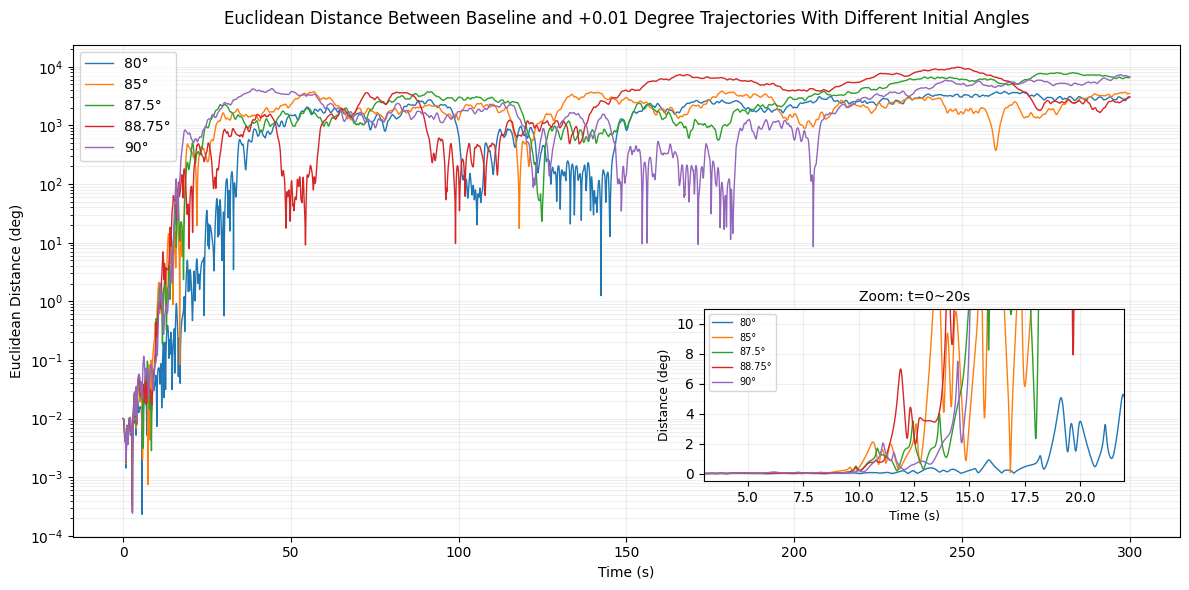

In [12]:
from numpy import size
import numpy as np

import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1.inset_locator import inset_axes



# 时间轴 (dt=0.01, 300s -> 30000步)

time = np.arange(len(distance_tables[80])) * 0.01



# ---- 图1：欧氏距离随时间变化（主图 + 放大框）----

fig, ax_main = plt.subplots(figsize=(12, 6))



for angle in angle_groups:

    ax_main.plot(time, distance_tables[angle], label=f"{angle}°", linewidth=1.0)



ax_main.set_xlabel("Time (s)")

ax_main.set_ylabel("Euclidean Distance (deg)")

ax_main.set_title("Euclidean Distance Between Baseline and +0.01 Degree Trajectories With Different Initial Angles", pad = 15)



# 主图图例放在左上角

ax_main.legend(loc="upper left")

ax_main.set_yscale("log")

ax_main.grid(True, which="both", alpha=0.2)



# ---- 放大框：精确固定在右下角内部 ----

# 核心修改：去掉复杂的 bbox_to_anchor

# loc="lower right" 会自动定位到右下角内部

# borderpad=2.5 表示让子图距离主图的右边缘和下边缘各留出 2.5 个单位的空隙，刚好避开主图的坐标轴标签

ax_inset = inset_axes(ax_main, width="38%", height="35%",

loc="lower right",

borderpad=4)



for angle in angle_groups:
    ax_inset.plot(time, distance_tables[angle], label=f"{angle}°", linewidth=1.0)



# 精确限制坐标轴显示范围
ax_inset.set_xlim(3, 22)
ax_inset.set_ylim(-0.5, 11)
ax_inset.set_xlabel("Time (s)", fontsize=9)
ax_inset.set_ylabel("Distance (deg)", fontsize=9)
ax_inset.set_title("Zoom: t=0~20s", fontsize=10)
ax_inset.legend(loc="upper left", fontsize=7)
ax_inset.grid(True, alpha=0.2)
# 用 tight_layout 优化边缘留白（这次不会再拉伸了）
plt.tight_layout()
plt.savefig("experiment_3.png", dpi = 600, bbox_inches = 'tight')
plt.savefig("experiment_3.pdf", bbox_inches = 'tight')
plt.show() 


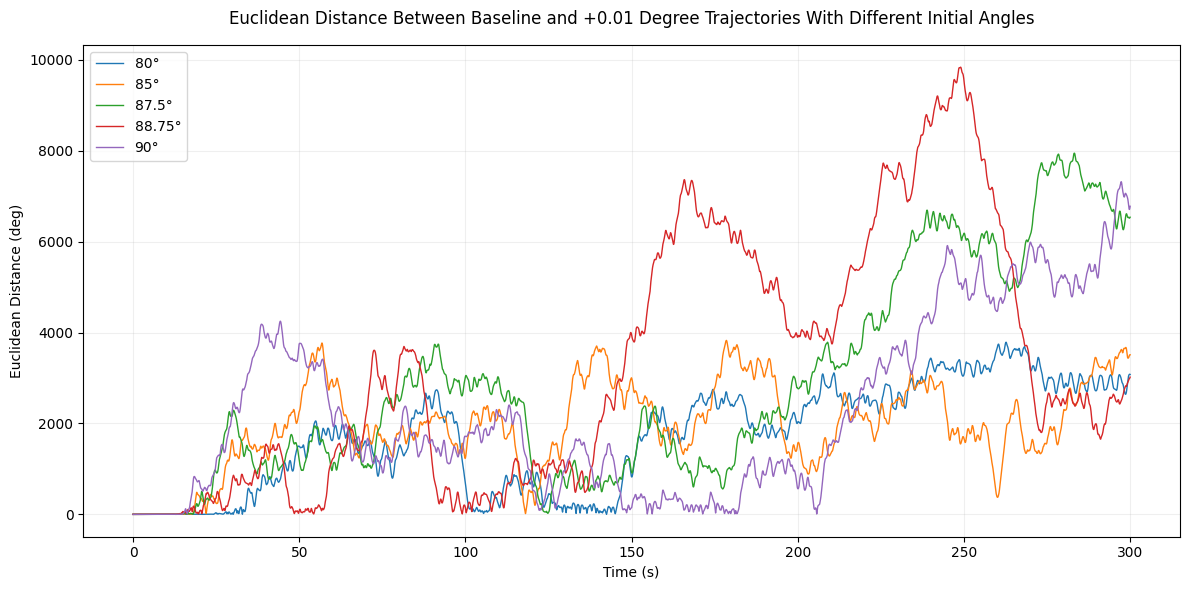

In [15]:
from numpy import size
import numpy as np

import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1.inset_locator import inset_axes



# 时间轴 (dt=0.01, 300s -> 30000步)

time = np.arange(len(distance_tables[80])) * 0.01



# ---- 图1：欧氏距离随时间变化（主图 + 放大框）----

fig, ax_main = plt.subplots(figsize=(12, 6))



for angle in angle_groups:

    ax_main.plot(time, distance_tables[angle], label=f"{angle}°", linewidth=1.0)



ax_main.set_xlabel("Time (s)")

ax_main.set_ylabel("Euclidean Distance (deg)")

ax_main.set_title("Euclidean Distance Between Baseline and +0.01 Degree Trajectories With Different Initial Angles", pad = 15)



# 主图图例放在左上角

ax_main.legend(loc="upper left")

#ax_main.set_yscale("log")

ax_main.grid(True, which="both", alpha=0.2)



# ---- 放大框：精确固定在右下角内部 ----

# 核心修改：去掉复杂的 bbox_to_anchor

# loc="lower right" 会自动定位到右下角内部

# borderpad=2.5 表示让子图距离主图的右边缘和下边缘各留出 2.5 个单位的空隙，刚好避开主图的坐标轴标签



# 精确限制坐标轴显示范围

# 用 tight_layout 优化边缘留白（这次不会再拉伸了）
plt.tight_layout()
plt.savefig("experiment_3_linear.png", dpi = 600, bbox_inches = 'tight')
plt.savefig("experiment_3_linear.pdf", bbox_inches = 'tight')
plt.show() 
